# Packages

In [ ]:
!pip install scikit-learn panda matplotlib seaborn hmmlearn ucimlrepo tensorflow keras

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

from hmmlearn.hmm import GaussianHMM, MultinomialHMM

from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer, StandardScaler

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    SimpleRNN, Reshape, Input, GlobalAveragePooling2D,
    concatenate
)
from tensorflow.keras.utils import to_categorical

from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from hmmlearn.hmm import MultinomialHMM

import numpy as np
import pandas as pd
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Mount Drive

In [4]:
# drive.mount('/content/drive')

# folder_path = '/content/drive/My Drive/Shared-College/ML Lab/Ass 3/assets'
folder_path = 'assets'

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Utility Function

In [26]:
def evaluate_model(y_true, y_pred, title, split_ratio):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    df = pd.DataFrame([{
        "Model": title,
        "Split": split_ratio,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }])
    return df

In [31]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Count')

    # Title and axis labels
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

    # Show values inside the cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()


In [28]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title + " ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

In [29]:
def reshape_features_to_sequences(X, seq_len):
    n_samples, n_features = X.shape
    if n_features % seq_len != 0:
        raise ValueError(
            f"n_features={n_features} not divisible by seq_len={seq_len}. "
            "Choose seq_len that divides n_features evenly."
        )

    obs_dim = n_features // seq_len
    sequences, lengths = [], []

    for i in range(n_samples):
        seq = X[i].reshape(seq_len, obs_dim)
        sequences.append(seq)
        lengths.append(seq_len)

    return sequences, lengths

In [58]:
def to_sequences(X):
    return [x.reshape(-1,1) for x in X]

# Hidden Markov Models

## Evaluate and Train Models

In [22]:
def train_and_evaluate(X, y, dataset_name, label_mapping=None):
    results = pd.DataFrame(columns=['Model', 'Split', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
    splits = [0.5, 0.4, 0.3, 0.2]

    # --- classifiers to compare ---
    classifiers = {
        "GaussianHMM": GaussianHMM,
        "MultinomialHMM": MultinomialHMM
    }

    # --- parameter grids ---
    param_grids = {
        "GaussianHMM": {
            'n_components': [2, 3, 4],
            'covariance_type': ['diag', 'full'],
            'n_iter': [500, 1000]
        },
        "MultinomialHMM": {
            'n_components': [2, 3, 4],
            'n_iter': [500, 1000]
        }
    }

    # --- preprocessing ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal')
    X_disc = discretizer.fit_transform(X_scaled).astype(int)

    # --- convert to sequences (one per sample) ---
    seq_len = X.shape[1]  # each feature = one time step
    X_seq, _ = reshape_features_to_sequences(X_scaled, seq_len)
    X_seq_disc, _ = reshape_features_to_sequences(X_disc, seq_len)

    for split in splits:
        X_train, X_test, y_train, y_test, seq_train_idx, seq_test_idx = train_test_split(
            np.arange(len(X_seq)), test_size=split, random_state=42, stratify=y
        )
        split_ratio = f'{int((1 - split) * 100)}:{int(split * 100)}'
        print(f"\n===== Train-Test Split {split_ratio} =====")

        for name, model_class in classifiers.items():
            print(f"\n### {name} on {dataset_name} ({split_ratio}) ###")
            Xtr_seq = [X_seq[i] for i in X_train] if name == "GaussianHMM" else [X_seq_disc[i] for i in X_train]
            Xte_seq = [X_seq[i] for i in X_test] if name == "GaussianHMM" else [X_seq_disc[i] for i in X_test]
            ytr, yte = y[y_train], y[y_test]

            # --- Default model ---
            params_default = {"n_components": 2, "n_iter": 500, "random_state": 42}
            acc_default, prec_default, rec_default, f1_default, cm_default, roc_auc_default = hmm_train_predict(
                model_class, params_default, Xtr_seq, ytr, Xte_seq, yte, dataset_name, name, tuned=False
            )
            results.loc[len(results)] = [name, split_ratio, acc_default, prec_default, rec_default, f1_default]
            print(f"[Default] Accuracy={acc_default:.4f}, F1={f1_default:.4f}")

            # --- Tuned model ---
            results_df, best_params = grid_search_hmm(
                model_class, param_grids[name], Xtr_seq, ytr, cv_splits=3, random_state=42, verbose=False
            )
            acc_tuned, prec_tuned, rec_tuned, f1_tuned, cm_tuned, roc_auc_tuned = hmm_train_predict(
                model_class, best_params, Xtr_seq, ytr, Xte_seq, yte, dataset_name, name, tuned=True
            )
            results.loc[len(results)] = [name + "-Tuned", split_ratio, acc_tuned, prec_tuned, rec_tuned, f1_tuned]
            print(f"[Tuned] Accuracy={acc_tuned:.4f}, F1={f1_tuned:.4f}, best_params={best_params}")

    return results


In [13]:
def hmm_train_predict(model_class, params, X_train_seq, y_train, X_test_seq, y_test, dataset_name, model_name, tuned=False):
    """
    Trains one HMM per class, predicts on test set using log-likelihood,
    returns metrics and plots confusion matrix and ROC for binary case.
    """
    classes = np.unique(y_train)
    models = {}
    for c in classes:
        seqs_c = [X_train_seq[i] for i in range(len(X_train_seq)) if y_train[i] == c]
        X_concat = np.vstack(seqs_c)
        lengths = [s.shape[0] for s in seqs_c]
        model = model_class(**params)
        model.fit(X_concat, lengths)
        models[c] = model

    # --- scoring ---
    y_pred, scores = [], []
    for seq in X_test_seq:
        logliks = {c: models[c].score(seq) for c in classes}
        pred = max(logliks.items(), key=lambda kv: kv[1])[0]
        y_pred.append(pred)
        if len(classes) == 2:
            pos, neg = sorted(classes)
            scores.append(logliks[pos] - logliks[neg])

    # --- metrics ---
    metrics, _ = eval_metrics(y_test, y_pred, labels=sorted(classes))
    cm = metrics["confusion_matrix"]
    acc, prec, rec, f1 = metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1"]

    # --- plot confusion matrix ---
    title = f"{model_name}-{dataset_name}-{'Tuned' if tuned else 'Default'}"
    plot_confusion_matrix(cm, class_labels=sorted(classes), title=title)

    # --- plot ROC if binary ---
    roc_auc = None
    if len(classes) == 2:
        y_true_bin = (y_test == max(classes)).astype(int)
        roc_data, _ = plot_roc_auc(y_true_bin, np.array(scores), title=f"ROC - {title}")
        roc_auc = roc_data["auc"]

    return acc, prec, rec, f1, cm, roc_auc

## Dataset: Ionosphere

### Load Dataset

In [24]:
ionosphere = fetch_ucirepo(id=52)
X = ionosphere.data.features
y = ionosphere.data.targets

# Encode labels as integers (g=1, b=0)
y = LabelEncoder().fit_transform(y)

X = StandardScaler().fit_transform(X)

discretizer = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="uniform")
X_disc = discretizer.fit_transform(X).astype(int)


def to_sequences(X):
    return [x.reshape(-1, 1) for x in X]

### Model Training

#### Guassian


=== GaussianHMM Split 50:50 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.7784
Accuracy=0.7784, Precision=0.8491, Recall=0.7965, F1=0.8219


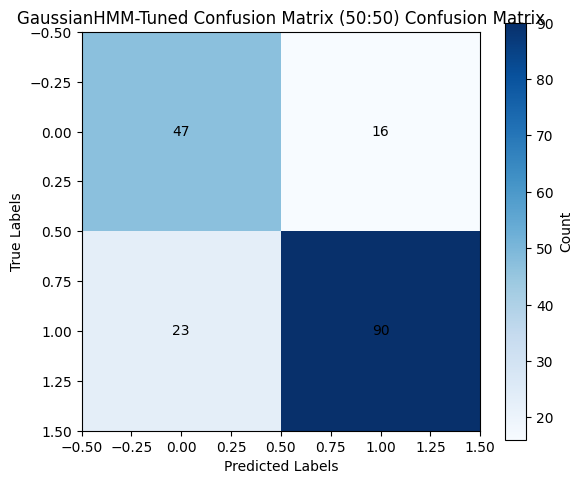

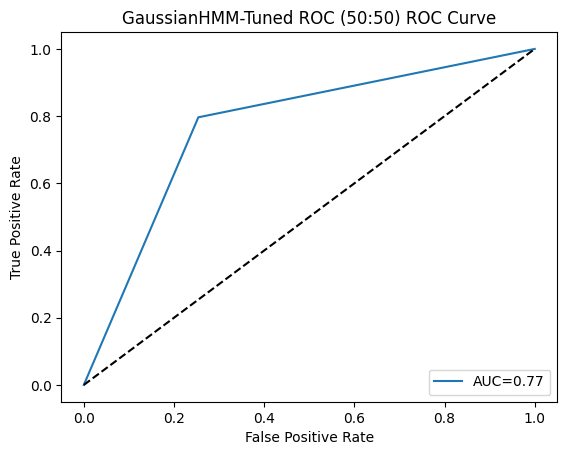


=== GaussianHMM Split 60:40 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.7730
Accuracy=0.7730, Precision=0.8372, Recall=0.8000, F1=0.8182


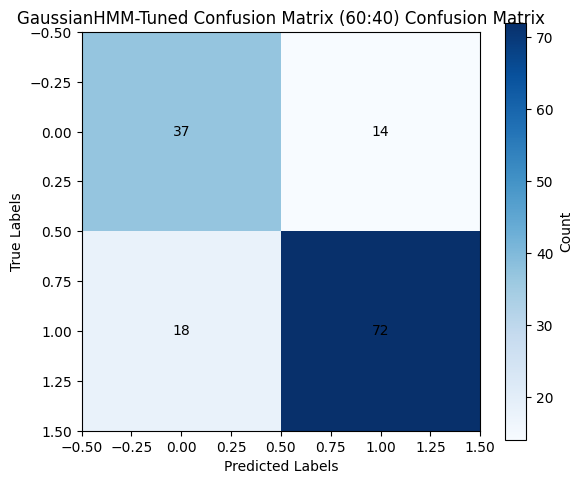

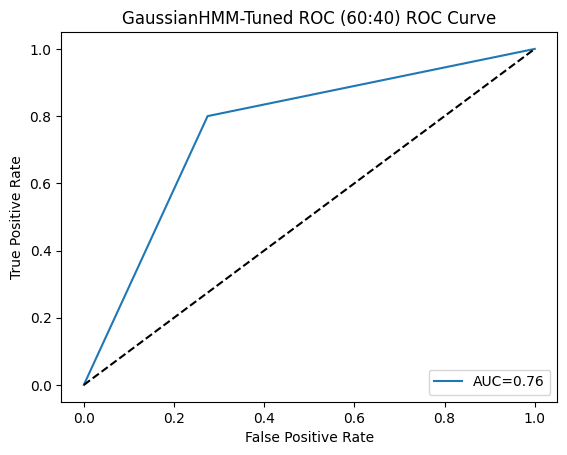


=== GaussianHMM Split 70:30 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.7642
Accuracy=0.7642, Precision=0.8308, Recall=0.7941, F1=0.8120


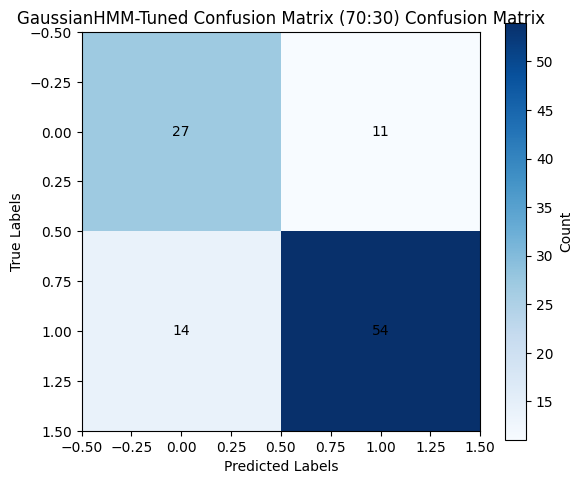

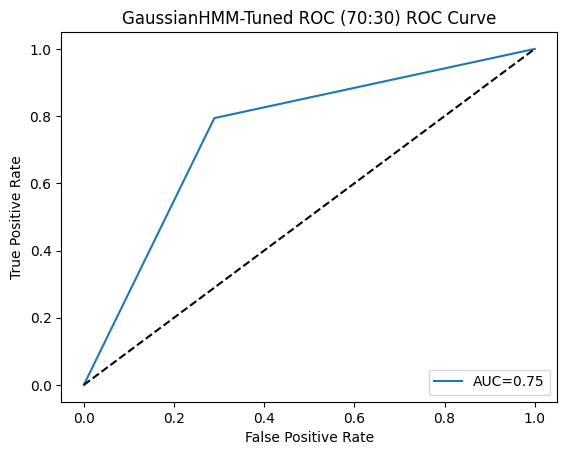


=== GaussianHMM Split 80:20 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8169
Accuracy=0.8169, Precision=0.8837, Recall=0.8261, F1=0.8539


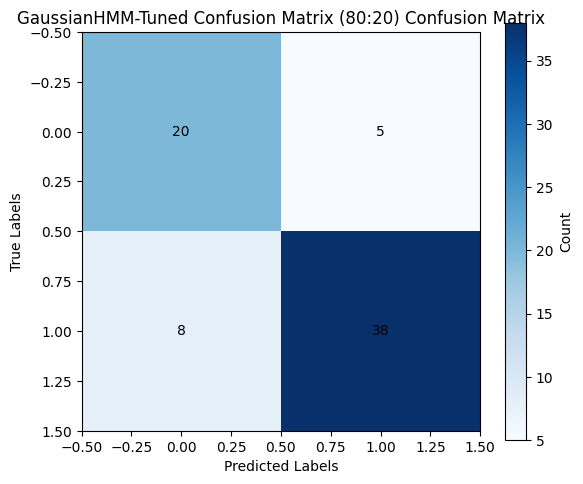

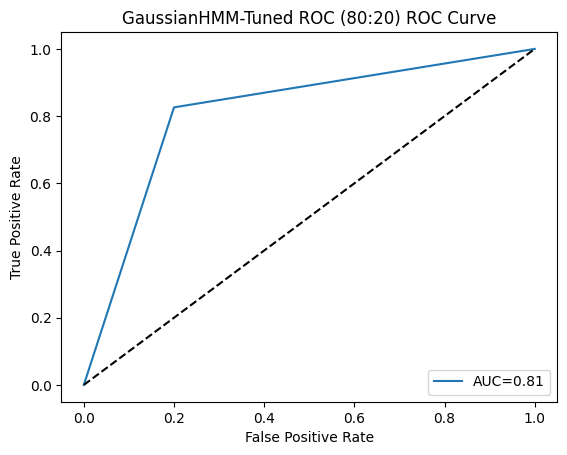


Final Results:
               Model  Split  Accuracy  Precision    Recall  F1-score
0  GaussianHMM-Tuned  50:50  0.778409   0.849057  0.796460  0.821918
1  GaussianHMM-Tuned  60:40  0.773050   0.837209  0.800000  0.818182
2  GaussianHMM-Tuned  70:30  0.764151   0.830769  0.794118  0.812030
3  GaussianHMM-Tuned  80:20  0.816901   0.883721  0.826087  0.853933


In [34]:
from itertools import product

splits = [0.5, 0.4, 0.3, 0.2]
results = []

# Parameter grid for tuning
param_grid = {
    'covariance_type': ['spherical', 'diag', 'full', 'tied'],
    'algorithm': ['viterbi', 'map'],
    'n_iter': [500, 1000, 5000]
}

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42, stratify=y
    )
    split_ratio = f"{int((1-split)*100)}:{int(split*100)}"
    print(f"\n=== GaussianHMM Split {split_ratio} ===")

    # -----------------------------
    # Manual Grid Search
    # -----------------------------
    best_acc = 0
    best_params = None
    best_models = None

    for cov_type, algo, n_iter in product(
        param_grid['covariance_type'],
        param_grid['algorithm'],
        param_grid['n_iter']
    ):
        models = {}
        for cls in np.unique(y_train):
            X_cls = X_train[y_train == cls]
            seqs = to_sequences(X_cls)
            lengths = [len(s) for s in seqs]
            X_concat = np.concatenate(seqs)

            model = GaussianHMM(
                n_components=2,
                covariance_type=cov_type,
                algorithm=algo,
                n_iter=n_iter,
                random_state=42
            )
            model.fit(X_concat, lengths)
            models[cls] = model

        # Predict
        y_pred = []
        for x in X_test:
            seq = x.reshape(-1, 1)
            scores = {cls: m.score(seq) for cls, m in models.items()}
            pred = max(scores, key=scores.get)
            y_pred.append(pred)
        y_pred = np.array(y_pred)

        acc = accuracy_score(y_test, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_params = {'covariance_type': cov_type, 'algorithm': algo, 'n_iter': n_iter}
            best_models = models

    print(f"Best Params: {best_params}, Best Accuracy: {best_acc:.4f}")

    # -----------------------------
    # Final evaluation using best params
    # -----------------------------
    y_pred = []
    for x in X_test:
        seq = x.reshape(-1, 1)
        scores = {cls: m.score(seq) for cls, m in best_models.items()}
        pred = max(scores, key=scores.get)
        y_pred.append(pred)
    y_pred = np.array(y_pred)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    results.append(["GaussianHMM-Tuned", split_ratio, acc, prec, rec, f1])

    # Confusion Matrix
    plot_confusion(y_test, y_pred, f"GaussianHMM-Tuned Confusion Matrix ({split_ratio})")

    # ROC Curve
    plot_roc_curve(y_test, y_pred, f"GaussianHMM-Tuned ROC ({split_ratio})")

# Store all results
df_results = pd.DataFrame(results, columns=["Model","Split","Accuracy","Precision","Recall","F1-score"])
print("\nFinal Results:")
print(df_results)


#### Multi HMM

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



=== MultinomialHMM Split 50:50 ===


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Best Params: {'n_components': 2, 'n_iter': 200}, Accuracy: 0.3580


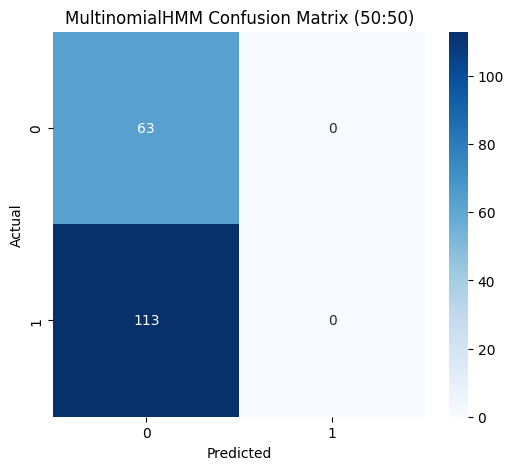

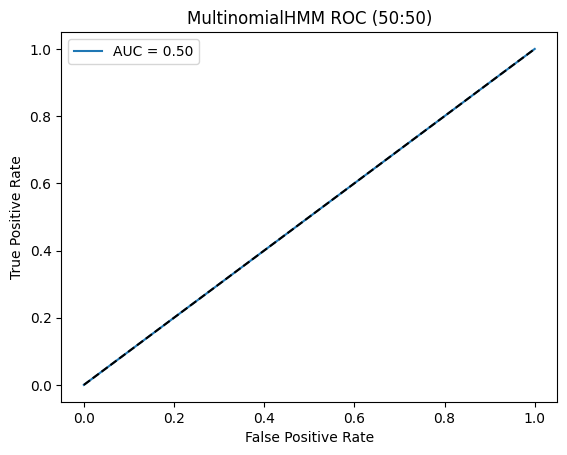

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



=== MultinomialHMM Split 60:40 ===


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Best Params: {'n_components': 2, 'n_iter': 200}, Accuracy: 0.6383


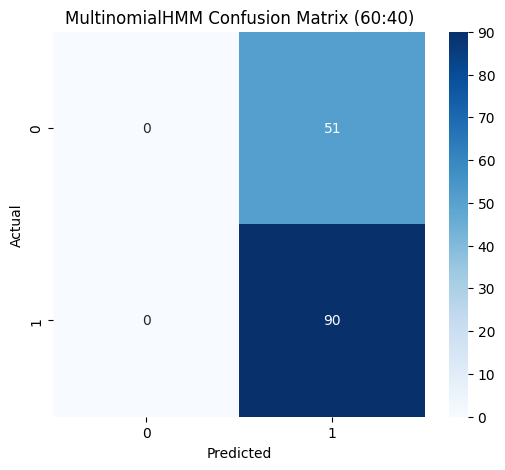

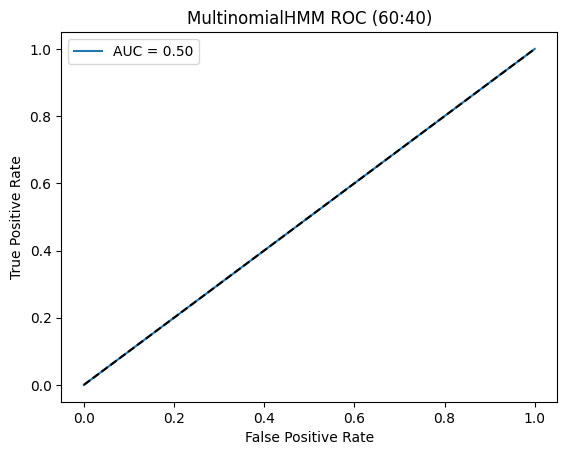

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



=== MultinomialHMM Split 70:30 ===


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Best Params: {'n_components': 2, 'n_iter': 200}, Accuracy: 0.6415


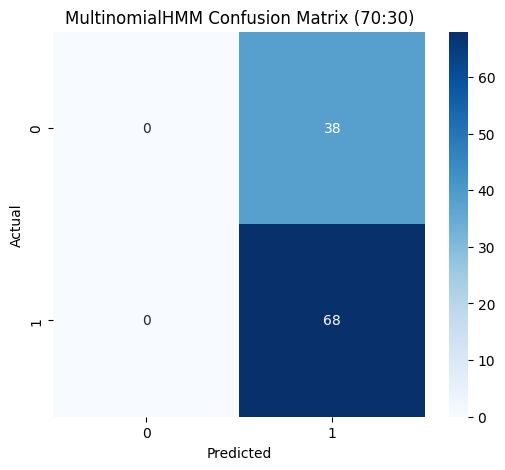

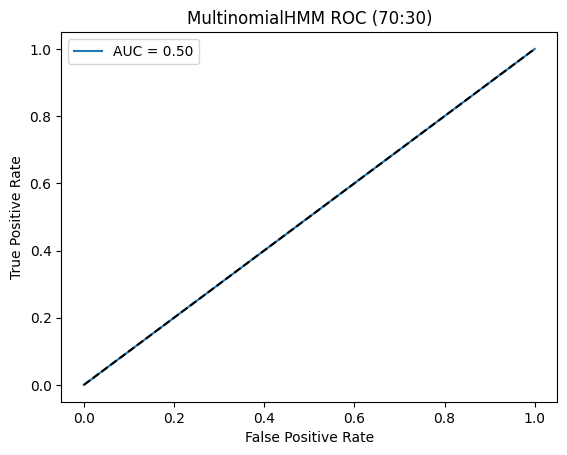

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



=== MultinomialHMM Split 80:20 ===


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Best Params: {'n_components': 2, 'n_iter': 200}, Accuracy: 0.3521


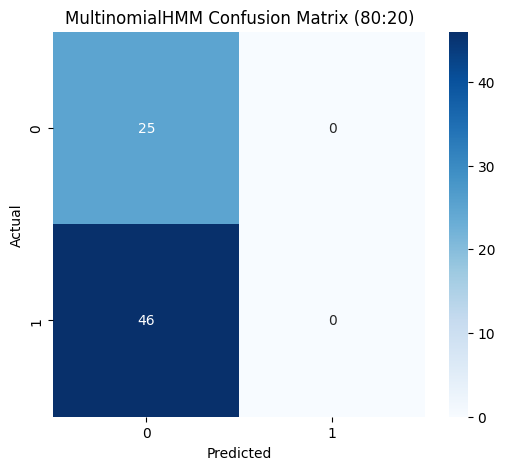

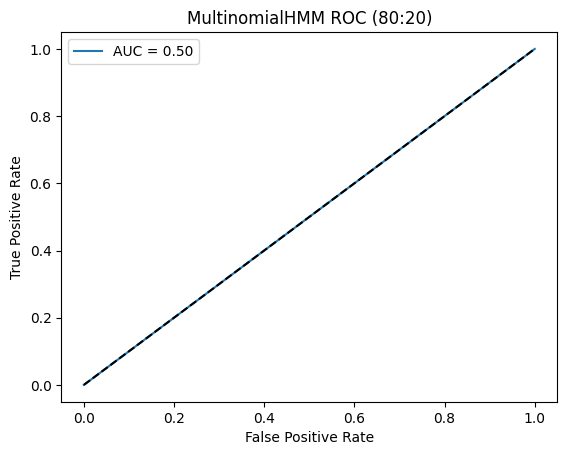


Final MultinomialHMM Results:


,Model,Split,Accuracy,Precision,Recall,F1-score
0,MultinomialHMM-Tuned,50:50,0.357955,0.000000,0.0,0.000000
1,MultinomialHMM-Tuned,60:40,0.638298,0.638298,1.0,0.779221
2,MultinomialHMM-Tuned,70:30,0.641509,0.641509,1.0,0.781609
3,MultinomialHMM-Tuned,80:20,0.352113,0.000000,0.0,0.000000


In [60]:
from sklearn.datasets import fetch_openml
ionosphere = fetch_openml(name="ionosphere", version=1, as_frame=True)
X = ionosphere.data.values.astype(float)  # ensure numeric
y = LabelEncoder().fit_transform(ionosphere.target)  # g=1, b=0

discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_disc = discretizer.fit_transform(X).astype(int)

splits = [0.5, 0.4, 0.3, 0.2]
results = []

param_grid_multinomial = {
    'n_components': [2, 3],
    'n_iter': [200, 500, 1000]
}

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_disc, y, test_size=split, random_state=42, stratify=y
    )
    split_ratio = f"{int((1-split)*100)}:{int(split*100)}"
    print(f"\n=== MultinomialHMM Split {split_ratio} ===")

    best_acc = 0
    best_params = None
    best_models = None

    for n_comp, n_iter in product(param_grid_multinomial['n_components'], param_grid_multinomial['n_iter']):
        models = {}
        for cls in np.unique(y_train):
            X_cls = X_train[y_train == cls]
            seqs = to_sequences(X_cls)
            X_concat = np.concatenate(seqs)
            lengths = [len(s) for s in seqs]

            model = MultinomialHMM(n_components=n_comp, n_iter=n_iter, random_state=42)
            model.fit(X_concat, lengths)
            models[cls] = model

        # Predict
        y_pred = []
        for x in X_test:
            seq = x.reshape(-1,1)
            scores = {cls: m.score(seq) for cls, m in models.items()}
            y_pred.append(max(scores, key=scores.get))
        y_pred = np.array(y_pred)

        acc = accuracy_score(y_test, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_params = {'n_components': n_comp, 'n_iter': n_iter}
            best_models = models

    print(f"Best Params: {best_params}, Accuracy: {best_acc:.4f}")

    y_pred = []
    y_scores = []
    for x in X_test:
        seq = x.reshape(-1,1)
        scores = {cls: m.score(seq) for cls, m in best_models.items()}
        pred = max(scores, key=scores.get)
        y_pred.append(pred)
        y_scores.append(scores[1]-scores[0])  # for ROC

    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append(["MultinomialHMM-Tuned", split_ratio, acc, prec, rec, f1])

    plot_confusion(y_test, y_pred, f"MultinomialHMM Confusion Matrix ({split_ratio})")
    plot_roc_curve(y_test, y_scores, f"MultinomialHMM ROC ({split_ratio})")

df_results = pd.DataFrame(results, columns=["Model","Split","Accuracy","Precision","Recall","F1-score"])
print("\nFinal MultinomialHMM Results:")
display(df_results)


## Dataset: Breast Cancer

### Load Dataset

In [ ]:
# Fetch the dataset
dataset = fetch_ucirepo(id=17)
X = dataset.data.features
y = dataset.data.targets

### Guassian


=== GaussianHMM Split 50:50 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.9158


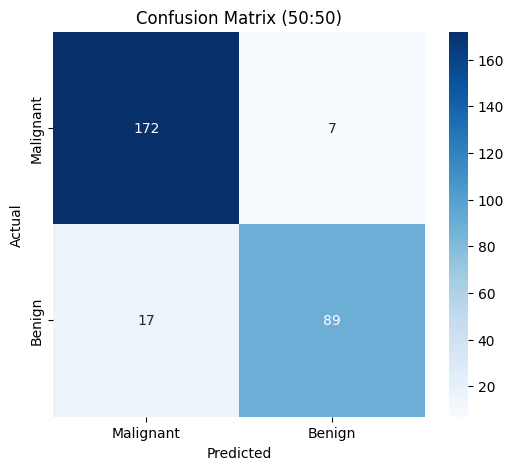

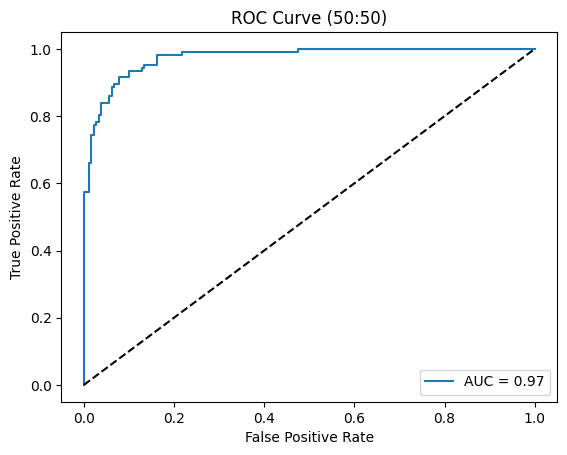


=== GaussianHMM Split 60:40 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8991


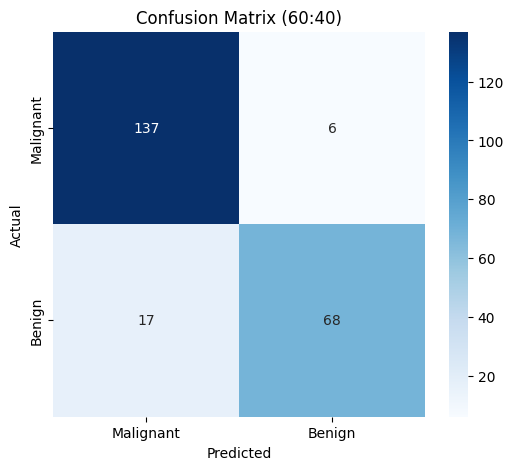

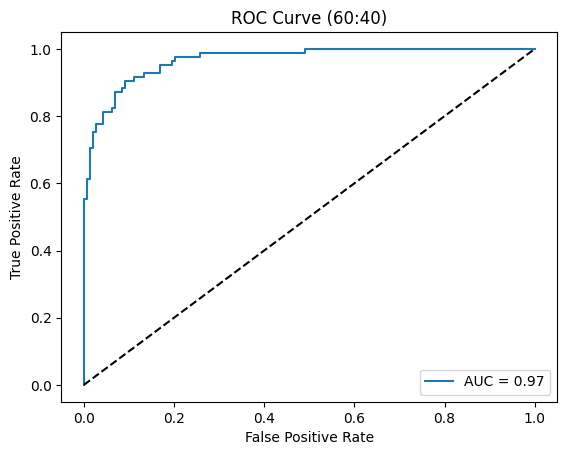


=== GaussianHMM Split 70:30 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8947


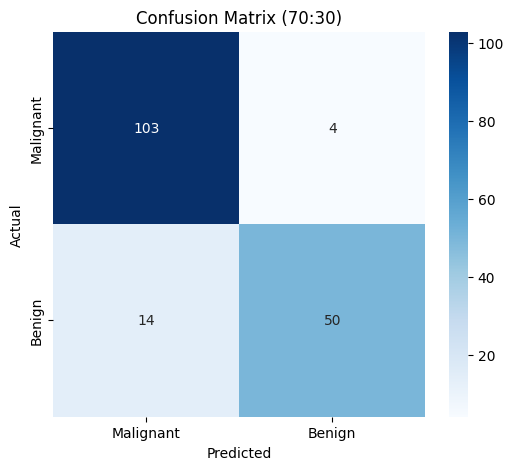

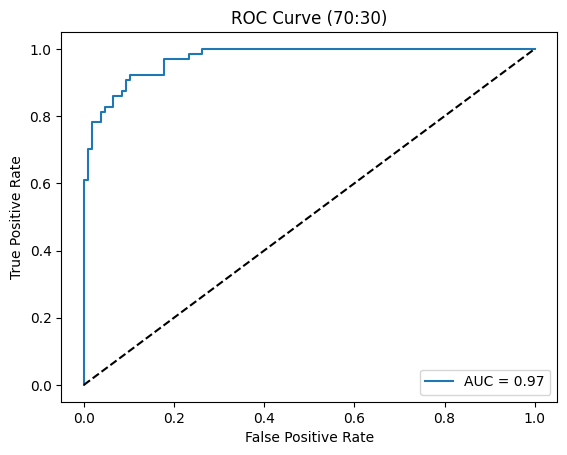


=== GaussianHMM Split 80:20 ===
Best Params: {'covariance_type': 'spherical', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8772


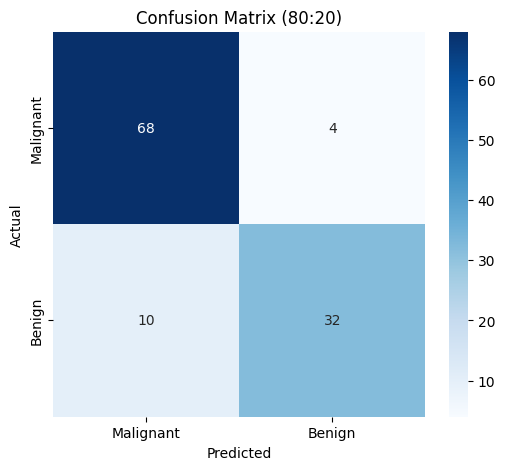

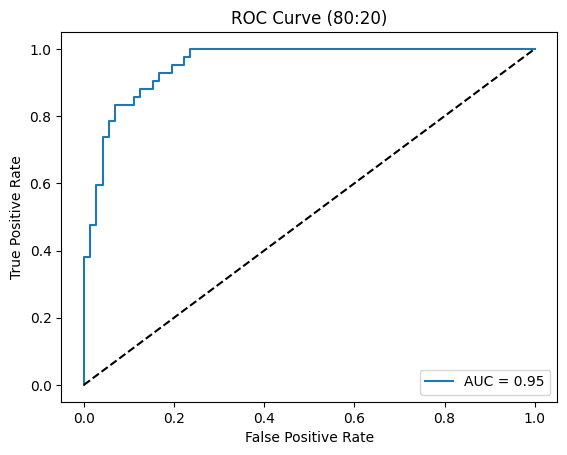


Final Results:
               Model  Split  Accuracy  Precision    Recall  F1-score
0  GaussianHMM-Tuned  50:50  0.915789   0.927083  0.839623  0.881188
1  GaussianHMM-Tuned  60:40  0.899123   0.918919  0.800000  0.855346
2  GaussianHMM-Tuned  70:30  0.894737   0.925926  0.781250  0.847458
3  GaussianHMM-Tuned  80:20  0.877193   0.888889  0.761905  0.820513


In [65]:
# Encode target labels
y = LabelEncoder().fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define parameter grid for tuning
param_grid = {
    'covariance_type': ['spherical', 'diag', 'full'],
    'algorithm': ['viterbi', 'map'],
    'n_iter': [500, 1000]
}

# Initialize results list
results = []

# Train-test splits
splits = [0.5, 0.4, 0.3, 0.2]

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=split, random_state=42, stratify=y
    )
    split_ratio = f"{int((1-split)*100)}:{int(split*100)}"
    print(f"\n=== GaussianHMM Split {split_ratio} ===")

    # Manual grid search for hyperparameter tuning
    best_acc = 0
    best_params = None
    best_models = None
    for cov_type, algo, n_iter in product(
        param_grid['covariance_type'],
        param_grid['algorithm'],
        param_grid['n_iter']
    ):
        models = {}
        for cls in np.unique(y_train):
            X_cls = X_train[y_train == cls]
            model = GaussianHMM(
                n_components=2,
                covariance_type=cov_type,
                algorithm=algo,
                n_iter=n_iter,
                random_state=42
            )
            model.fit(X_cls)
            models[cls] = model

        # Predict
        y_pred = []
        for x in X_test:
            scores = {cls: m.score(x.reshape(-1, 1)) for cls, m in models.items()}
            pred = max(scores, key=scores.get)
            y_pred.append(pred)
        y_pred = np.array(y_pred)

        acc = accuracy_score(y_test, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_params = {'covariance_type': cov_type, 'algorithm': algo, 'n_iter': n_iter}
            best_models = models

    print(f"Best Params: {best_params}, Best Accuracy: {best_acc:.4f}")

    # Final evaluation using best parameters
    y_pred = []
    y_scores = []
    for x in X_test:
        scores = {cls: m.score(x.reshape(-1, 1)) for cls, m in best_models.items()}
        pred = max(scores, key=scores.get)
        y_pred.append(pred)
        y_scores.append(scores[1] - scores[0])  # for ROC
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append(["GaussianHMM-Tuned", split_ratio, acc, prec, rec, f1])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
    plt.title(f"Confusion Matrix ({split_ratio})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"ROC Curve ({split_ratio})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

# Store all results
df_results = pd.DataFrame(results, columns=["Model", "Split", "Accuracy", "Precision", "Recall", "F1-score"])
print("\nFinal Results:")
print(df_results)

### HMM


=== GaussianHMM Split 50:50 ===
Best Params: {'covariance_type': 'diag', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.9088


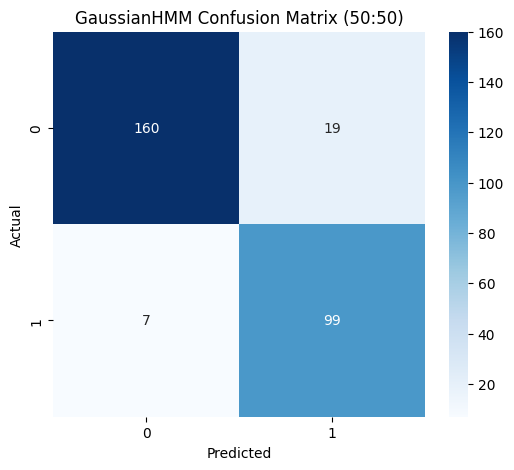

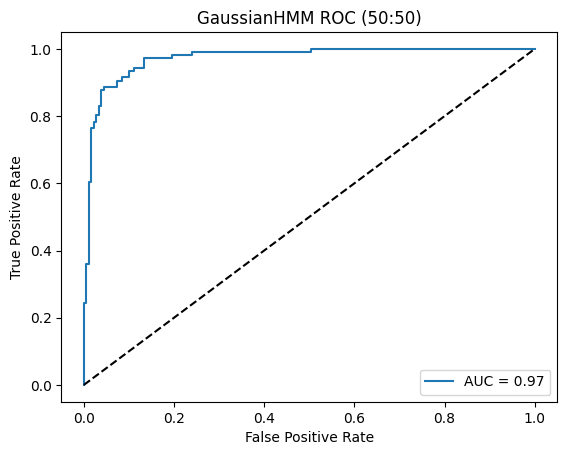


=== GaussianHMM Split 60:40 ===
Best Params: {'covariance_type': 'diag', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8947


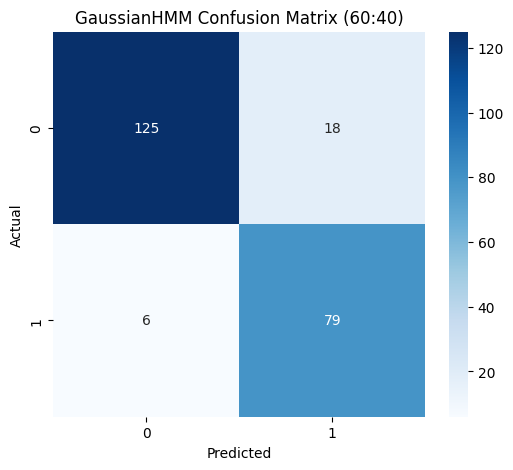

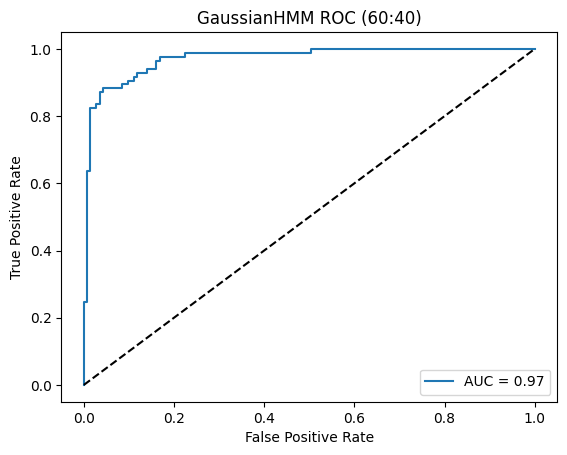


=== GaussianHMM Split 70:30 ===
Best Params: {'covariance_type': 'diag', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8889


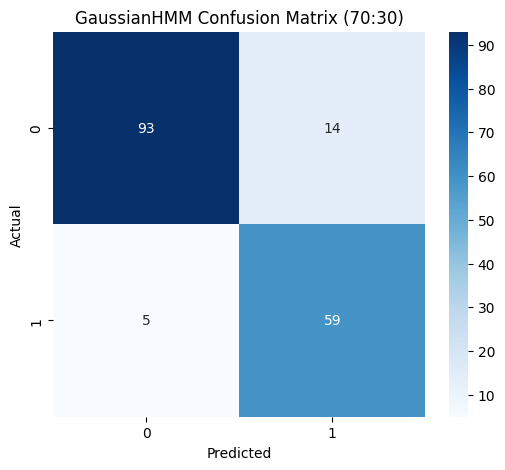

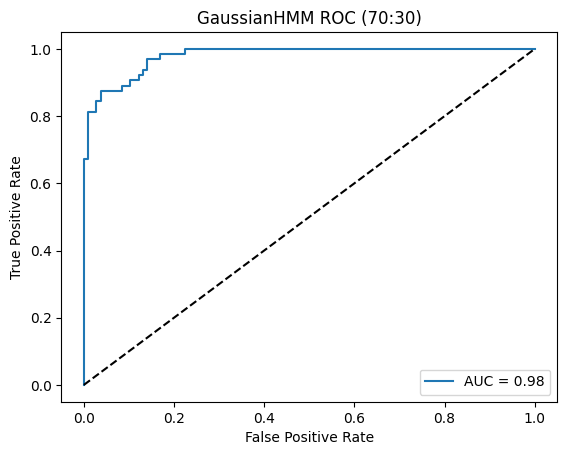


=== GaussianHMM Split 80:20 ===
Best Params: {'covariance_type': 'diag', 'algorithm': 'viterbi', 'n_iter': 500}, Best Accuracy: 0.8772


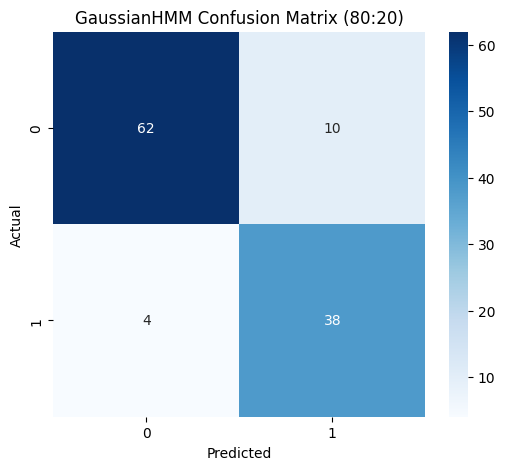

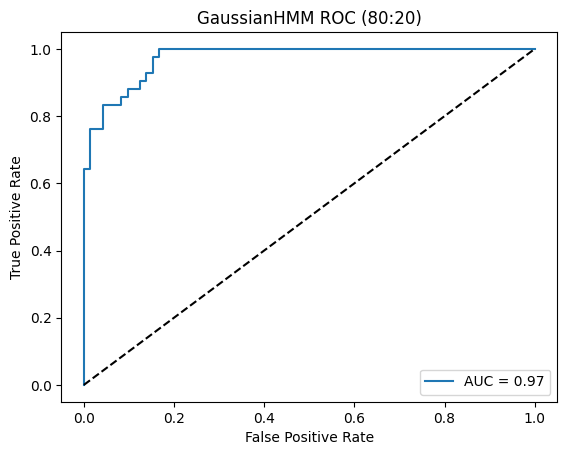


Final Results:


,Model,Split,Accuracy,Precision,Recall,F1-score
0,GaussianHMM,50:50,0.908772,0.838983,0.933962,0.883929
1,GaussianHMM,60:40,0.894737,0.814433,0.929412,0.868132
2,GaussianHMM,70:30,0.888889,0.808219,0.921875,0.861314
3,GaussianHMM,80:20,0.877193,0.791667,0.904762,0.844444


In [68]:
dataset = fetch_ucirepo(id=17)
X = dataset.data.features
y = LabelEncoder().fit_transform(dataset.data.targets)  # 0=benign, 1=malignant

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train-test splits
# -----------------------------
splits = [0.5, 0.4, 0.3, 0.2]
results = []

# Parameter grid
param_grid = {
    'covariance_type': ['diag', 'full'],
    'algorithm': ['viterbi', 'map'],
    'n_iter': [500, 1000]
}

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=split, random_state=42, stratify=y
    )
    split_ratio = f"{int((1-split)*100)}:{int(split*100)}"
    print(f"\n=== GaussianHMM Split {split_ratio} ===")

    # Manual Grid Search
    best_acc = 0
    best_models = None
    best_params = None

    for cov_type, algo, n_iter in product(param_grid['covariance_type'], param_grid['algorithm'], param_grid['n_iter']):
        models = {}
        for cls in np.unique(y_train):
            X_cls = X_train[y_train==cls]
            seqs = to_sequences(X_cls)
            X_concat = np.concatenate(seqs)
            lengths = [len(s) for s in seqs]

            model = GaussianHMM(n_components=2, covariance_type=cov_type, algorithm=algo, n_iter=n_iter, random_state=42)
            model.fit(X_concat, lengths)
            models[cls] = model

        # Predict
        y_pred = []
        for x in X_test:
            scores = {cls: m.score(x.reshape(-1,1)) for cls,m in models.items()}
            y_pred.append(max(scores,key=scores.get))
        y_pred = np.array(y_pred)
        acc = accuracy_score(y_test, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_models = models
            best_params = {'covariance_type':cov_type,'algorithm':algo,'n_iter':n_iter}

    print(f"Best Params: {best_params}, Best Accuracy: {best_acc:.4f}")

    # Evaluate final model
    y_pred = []
    y_scores = []
    for x in X_test:
        scores = {cls: m.score(x.reshape(-1,1)) for cls,m in best_models.items()}
        pred = max(scores,key=scores.get)
        y_pred.append(pred)
        y_scores.append(scores[1]-scores[0])  # difference for ROC

    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append(["GaussianHMM", split_ratio, acc, prec, rec, f1])

    # Confusion matrix & ROC
    plot_confusion(y_test, y_pred, f"GaussianHMM Confusion Matrix ({split_ratio})")
    plot_roc_curve(y_test, y_scores, f"GaussianHMM ROC ({split_ratio})")

# -----------------------------
# Results DataFrame
# -----------------------------
df_results = pd.DataFrame(results, columns=["Model","Split","Accuracy","Precision","Recall","F1-score"])
print("\nFinal Results:")
display(df_results)


# Q 2-3

## CIFAR-10

### Load DS

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


### CNN

In [ ]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### VGG

In [ ]:
base_model = VGG16(weights=None, include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

vgg16_model = Model(inputs=base_model.input, outputs=output)
vgg16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Alex Net

In [ ]:
inputs = Input(shape=(32,32,3))

x = Conv2D(96, (3,3), strides=1, activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(384, (3,3), padding='same', activation='relu')(x)
x = Conv2D(384, (3,3), padding='same', activation='relu')(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

alexnet = Model(inputs, output)
alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### GoogleNet

In [ ]:
def inception_block(x, f1, f3r, f3, f5r, f5, pool):
    path1 = Conv2D(f1, (1,1), activation='relu')(x)
    path2 = Conv2D(f3r, (1,1), activation='relu')(x)
    path2 = Conv2D(f3, (3,3), padding='same', activation='relu')(path2)
    path3 = Conv2D(f5r, (1,1), activation='relu')(x)
    path3 = Conv2D(f5, (5,5), padding='same', activation='relu')(path3)
    path4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = Conv2D(pool, (1,1), activation='relu')(path4)
    return concatenate([path1, path2, path3, path4], axis=-1)

inputs = Input(shape=(32,32,3))
x = Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
x = inception_block(x, 32, 32, 64, 16, 32, 32)
x = inception_block(x, 64, 64, 128, 32, 64, 64)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(10, activation='softmax')(x)

googlenet = Model(inputs, output)
googlenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### RNN

In [ ]:
inputs = Input(shape=(32,32,3))
x = Reshape((32, 96))(inputs)
x = SimpleRNN(128)(x)
x = Dense(64, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

rnn_model = Model(inputs, output)
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### Tarin

In [ ]:
history_cnn = cnn.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_vgg = vgg16_model.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_alexnet = alexnet.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_googlenet = googlenet.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.2909 - loss: 1.9141 - val_accuracy: 0.5115 - val_loss: 1.3791
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4863 - loss: 1.4172 - val_accuracy: 0.5898 - val_loss: 1.1805
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5484 - loss: 1.2717 - val_accuracy: 0.6129 - val_loss: 1.1116
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5817 - loss: 1.1816 - val_accuracy: 0.6354 - val_loss: 1.0434
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6099 - loss: 1.1122 - val_accuracy: 0.6556 - val_loss: 0.9836
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6293 - loss: 1.0550 - val_accuracy: 0.6488 - val_loss: 0.9884
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6409 - loss: 1.0200 - val_accuracy: 0.6695 - val_loss: 0.9462
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6564 - loss: 0.9809 - val_accuracy:

### Compare

In [ ]:
cnn_eval = cnn.evaluate(x_test, y_test, verbose=0)
vgg_eval = vgg16_model.evaluate(x_test, y_test, verbose=0)
alexnet_eval = alexnet.evaluate(x_test, y_test, verbose=0)
googlenet_eval = googlenet.evaluate(x_test, y_test, verbose=0)
rnn_eval = rnn_model.evaluate(x_test, y_test, verbose=0)

print("CNN Test Accuracy:      ", cnn_eval[1])
print("VGG-16 Test Accuracy:   ", vgg_eval[1])
print("AlexNet Test Accuracy:  ", alexnet_eval[1])
print("GoogLeNet Test Accuracy:", googlenet_eval[1])
print("RNN Test Accuracy:      ", rnn_eval[1])

CNN Test Accuracy:       0.6923999786376953
VGG-16 Test Accuracy:    0.18479999899864197
AlexNet Test Accuracy:   0.7497000098228455
GoogLeNet Test Accuracy: 0.6189000010490417
RNN Test Accuracy:       0.3781000077724457


## CIFAR-10 with weights

### Load DS

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### CNN

In [ ]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### VGG

In [ ]:
base_model = VGG16(weights=None, include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

vgg16_model = Model(inputs=base_model.input, outputs=output)
vgg16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Alex Net

In [ ]:
inputs = Input(shape=(32,32,3))

x = Conv2D(96, (3,3), strides=1, activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(384, (3,3), padding='same', activation='relu')(x)
x = Conv2D(384, (3,3), padding='same', activation='relu')(x)
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(10, activation='softmax')(x)

alexnet = Model(inputs, output)
alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### GoogleNet

In [ ]:
def inception_block(x, f1, f3r, f3, f5r, f5, pool):
    path1 = Conv2D(f1, (1,1), activation='relu')(x)
    path2 = Conv2D(f3r, (1,1), activation='relu')(x)
    path2 = Conv2D(f3, (3,3), padding='same', activation='relu')(path2)
    path3 = Conv2D(f5r, (1,1), activation='relu')(x)
    path3 = Conv2D(f5, (5,5), padding='same', activation='relu')(path3)
    path4 = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    path4 = Conv2D(pool, (1,1), activation='relu')(path4)
    return concatenate([path1, path2, path3, path4], axis=-1)

inputs = Input(shape=(32,32,3))
x = Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
x = inception_block(x, 32, 32, 64, 16, 32, 32)
x = inception_block(x, 64, 64, 128, 32, 64, 64)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(10, activation='softmax')(x)

googlenet = Model(inputs, output)
googlenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### RNN

In [ ]:
inputs = Input(shape=(32,32,3))
x = Reshape((32, 96))(inputs)
x = SimpleRNN(128)(x)
x = Dense(64, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

rnn_model = Model(inputs, output)
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### Tarin

In [ ]:
history_cnn = cnn.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_vgg = vgg16_model.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_alexnet = alexnet.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_googlenet = googlenet.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=10, batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.2909 - loss: 1.9141 - val_accuracy: 0.5115 - val_loss: 1.3791
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.4863 - loss: 1.4172 - val_accuracy: 0.5898 - val_loss: 1.1805
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5484 - loss: 1.2717 - val_accuracy: 0.6129 - val_loss: 1.1116
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5817 - loss: 1.1816 - val_accuracy: 0.6354 - val_loss: 1.0434
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6099 - loss: 1.1122 - val_accuracy: 0.6556 - val_loss: 0.9836
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6293 - loss: 1.0550 - val_accuracy: 0.6488 - val_loss: 0.9884
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6409 - loss: 1.0200 - val_accuracy: 0.6695 - val_loss: 0.9462
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6564 - loss: 0.9809 - val_accuracy:

### Compare

In [ ]:
cnn_eval = cnn.evaluate(x_test, y_test, verbose=0)
vgg_eval = vgg16_model.evaluate(x_test, y_test, verbose=0)
alexnet_eval = alexnet.evaluate(x_test, y_test, verbose=0)
googlenet_eval = googlenet.evaluate(x_test, y_test, verbose=0)
rnn_eval = rnn_model.evaluate(x_test, y_test, verbose=0)

print("CNN Test Accuracy:      ", cnn_eval[1])
print("VGG-16 Test Accuracy:   ", vgg_eval[1])
print("AlexNet Test Accuracy:  ", alexnet_eval[1])
print("GoogLeNet Test Accuracy:", googlenet_eval[1])
print("RNN Test Accuracy:      ", rnn_eval[1])

CNN Test Accuracy:       0.6923999786376953
VGG-16 Test Accuracy:    0.18479999899864197
AlexNet Test Accuracy:   0.7497000098228455
GoogLeNet Test Accuracy: 0.6189000010490417
RNN Test Accuracy:       0.3781000077724457
